In [1]:
import pandas as pd
from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report
import numpy as np

In [2]:
df = pd.read_csv("../data/processed/engineered_dataset.csv")

features = [
    'failure_rate',
    'port_scan_intensity',
    'process_cpu_ratio',
    'packet_spike_ratio',
    'connection_spike_ratio',
    'cpu_spike_ratio'
]

# Preprocess
df = df.replace([np.inf, -np.inf], np.nan).fillna(0)

for col in ['process_cpu_ratio', 'packet_spike_ratio', 'connection_spike_ratio']:
    df[col] = np.log1p(df[col])

X = df[features]
y = df['is_attack']

In [3]:
X_train = X[y == 0]
X_test = X

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [4]:
results = []

for c in [0.1, 0.15, 0.2, 0.25, 0.3]:

    model = IsolationForest(
        contamination=c,
        random_state=42
    )
    
    model.fit(X_train_scaled)

    preds = model.predict(X_test_scaled)
    preds = [0 if p == 1 else 1 for p in preds]

    report = classification_report(y, preds, output_dict=True)
    
    accuracy = (preds == y).sum() / len(y)

    results.append({
        "contamination": c,
        "recall_attack": report['1']['recall'],
        "precision_attack": report['1']['precision'],
        "accuracy": accuracy,
        "f1_score": report['1']['f1-score']
    })

In [5]:
results_df = pd.DataFrame(results)
results_df

,contamination,recall_attack,precision_attack,accuracy,f1_score
0,0.10,0.873529,0.792000,0.891964,0.830769
1,0.15,0.914118,0.726848,0.869643,0.809797
2,0.20,0.949412,0.674185,0.845357,0.788471
3,0.25,0.965882,0.627436,0.815536,0.760713
4,0.30,0.976471,0.587195,0.784464,0.733378


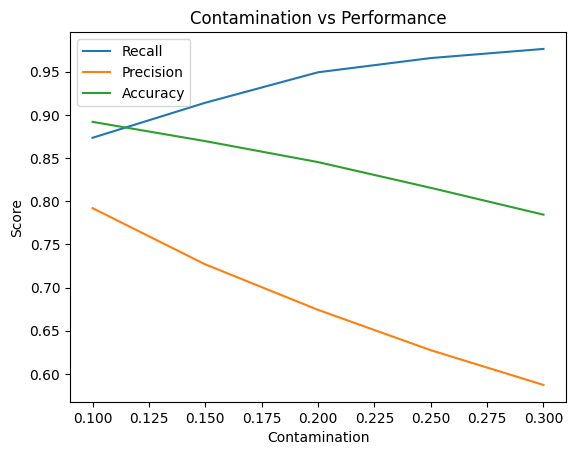

In [6]:
import matplotlib.pyplot as plt

plt.plot(results_df['contamination'], results_df['recall_attack'], label='Recall')
plt.plot(results_df['contamination'], results_df['precision_attack'], label='Precision')
plt.plot(results_df['contamination'], results_df['accuracy'], label='Accuracy')

plt.xlabel("Contamination")
plt.ylabel("Score")
plt.title("Contamination vs Performance")
plt.legend()
plt.show()

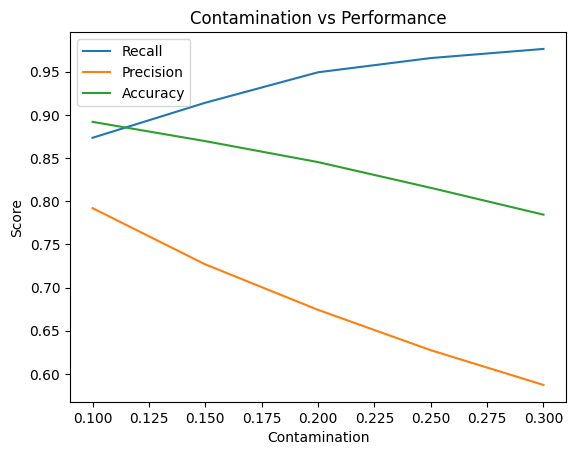

In [7]:
import matplotlib.pyplot as plt

plt.plot(results_df['contamination'], results_df['recall_attack'], label='Recall')
plt.plot(results_df['contamination'], results_df['precision_attack'], label='Precision')
plt.plot(results_df['contamination'], results_df['accuracy'], label='Accuracy')

plt.xlabel("Contamination")
plt.ylabel("Score")
plt.title("Contamination vs Performance")
plt.legend()
plt.show()